# Random Hostname Generator

Creation of an algorithm to generate 1500 hostnames, according to operating systems, environments, and countries.
Followed by the creation of a DataFrame to save them in a CSV file, and visualization of data for an analysis of the results.

# 1. Import Libraries

Import of libraries for generating random numbers, and for data manipulation and visualization.

In [67]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Initialization of Global Variables

Initialization of three global variables to use them in the creation of the algorithm and the DataFrame.

In [68]:
hostnames = []
dataset = []
df = None

# 3. Function to Generate `hostnames`

Creation of the `host_names` function composed of 8 alphanumeric characters (uppercase).

### Hostname Composition

<table style="width:100%; border-collapse: collapse; text-align:left; font-size:16px;">
<tr style="background-color:#eef1f8;">
<th style="padding:10px; border:1px solid #ccc;">Component</th>
<th style="padding:10px; border:1px solid #ccc;">Code</th>
<th style="padding:10px; border:1px solid #ccc;">Probability</th>
</tr>

<tr>
<td style="padding:10px; border:1px solid #ccc; background:#f9fbff;">
<b>Position 1:<br>Operating System</b>
</td>
<td style="padding:10px; border:1px solid #ccc;">
<span style="color:#4655AE;"><b>L</b> – Linux</span><br>
<span style="color:#F9734F;"><b>S</b> – Solaris</span><br>
<span style="color:#6E56A0;"><b>A</b> – AIX</span><br>
<span style="color:#F25D71;"><b>H</b> – HP-UX</span>
</td>
<td style="padding:10px; border:1px solid #ccc;">
40%<br>30%<br>20%<br>10%
</td>
</tr>

<tr style="background-color:#f9fbff;">
<td style="padding:10px; border:1px solid #ccc;">
<b>Position 2:<br>Environment</b>
</td>
<td style="padding:10px; border:1px solid #ccc;">
<span style="color:#F19A21;"><b>D</b> – Development</span><br>
<span style="color:#F32A78;"><b>I</b> – Integration</span><br>
<span style="color:#9ACA29;"><b>T</b> – Testing</span><br>
<span style="color:#00ABD7;"><b>S</b> – Staging</span><br>
<span style="color:#4655AE;"><b>P</b> – Production</span>
</td>
<td style="padding:10px; border:1px solid #ccc;">
10%<br>10%<br>25%<br>25%<br>30%
</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid #ccc; background:#f9fbff;">
<b>Positions 3–5:<br>Country</b>
</td>
<td style="padding:10px; border:1px solid #ccc;">
<span style="color:#9ACA29;"><b>NOR</b> – Norway</span><br>
<span style="color:#012290;"><b>FRA</b> – France</span><br>
<span style="color:#813696;"><b>ITA</b> – Italy</span><br>
<span style="color:#00ABD7;"><b>ESP</b> – Spain</span><br>
<span style="color:#F32A78;"><b>GER</b> – Germany</span><br>
<span style="color:#F9734F;"><b>IRL</b> – Ireland</span>
</td>
<td style="padding:10px; border:1px solid #ccc;">
6%<br>9%<br>16%<br>16%<br>23%<br>30%
</td>
</tr>

<tr style="background-color:#f9fbff;">
<td style="padding:10px; border:1px solid #ccc;">
<b>Positions 6–8:<br>Node</b>
</td>
<td style="padding:10px; border:1px solid #ccc;">
<b>001–999</b><br>(Node number)
</td>
<td style="padding:10px; border:1px solid #ccc;">—</td>
</tr>
</table>

Example: `AIGER789` (`A` → Operating System | `I` → Environment | `GER` → Country | `789` → Node)


In [69]:
def set_hostnames(number_of_hosts: int) -> None:
    operating_system = ['L']*40 + ['S']*30 + ['A']*20 + ['H']*10
    environment = ['D']*10 + ['I']*10 + ['T']*25 + ['S']*25 + ['P']*30
    country = ['NOR']*6 + ['FRA']*9 + ['ITA']*16 + ['ESP']*16 + ['GER']*23 + ['IRL']*30
    alpha_group = []

    for i in range(number_of_hosts):
        hostname = random.choice(operating_system) + random.choice(environment) + random.choice(country)
        node = random.randint(1, 999)
        hostname += str(node).zfill(3)
        hostnames.append(hostname)

# 4. Function to Obtain the `Operating System`

Create the `get_os` function to retrieve the OS.

In [70]:
def get_os (hostname: str) -> str:
    if hostname.startswith('L'):
        return 'Linux'
    elif hostname.startswith('S'):
        return 'Solaris'
    elif hostname.startswith('A'):
        return 'AIX'
    elif hostname.startswith('H'):
        return 'HP-UX'
    else:
        return 'Unknow'

# 5. Function to Obtain the `Environment`

Create the `get_environment` function to retrieve the environment.

In [71]:
def get_enviroment (hostname: str) -> str:
    if hostname[1] == 'D':
        return 'Development'
    elif hostname[1] == 'I':
        return 'Integration'
    elif hostname[1] == 'T':
        return 'Testing'
    elif hostname[1] == 'S':
        return 'Staging'
    elif hostname[1] == 'P':
        return 'Production'
    else:
        return 'Unknow'

# 6. Function to Obtain the `Country`

Create the `get_country` function to retrieve the country.

In [72]:
def get_country (hostname: str) -> str:
    if hostname[2:5] == 'NOR':
        return 'Norway'
    elif hostname[2:5] == 'GER':
        return 'Germany'
    elif hostname[2:5] == 'ITA':
        return 'Italy'
    elif hostname[2:5] == 'ESP':
        return 'Spain'
    elif hostname[2:5] == 'IRL':
        return 'Ireland'
    elif hostname[2:5] == 'FRA':
        return 'France'
    else:
        return 'Unknow'

# 7. Function to Generate the DataFrame

Create the `set_dataframe` function to generate the DataFrame.

In [73]:
def set_dataframe(count: int) -> None:
    global df

    set_hostnames(count)

    for hostname in hostnames:
        dataset.append({
            'hostname': hostname,
            'os': get_os(hostname),
            'environment': get_enviroment(hostname),
            'country': get_country(hostname),
            'node': int(hostname[-3:])
        })

# 8. Create the DataFrame

Creation of a DataFrame with 1500 records and printing of a random sample.

In [74]:
set_dataframe(1500)
df = pd.DataFrame(dataset)
display(df.sample(15))

,hostname,os,environment,country,node
1222,LSGER193,Linux,Staging,Germany,193
1260,ADITA434,AIX,Development,Italy,434
97,LSGER674,Linux,Staging,Germany,674
1267,SPFRA979,Solaris,Production,France,979
1193,LIIRL629,Linux,Integration,Ireland,629
966,STESP815,Solaris,Testing,Spain,815
5,LTIRL678,Linux,Testing,Ireland,678
1285,STGER183,Solaris,Testing,Germany,183
618,SSESP669,Solaris,Staging,Spain,669
812,ATIRL431,AIX,Testing,Ireland,431


# 9. Save the Generated DataFrame to a CSV File

The DataFrame file is created, read with pandas, and the head and tail are displayed.

We can see that the shape is 1500 rows and 5 columns.

In [75]:
df.to_csv('hosts.csv', header=True, index=False)

df_hosts = pd.read_csv('hosts.csv')

display(df_hosts)

,hostname,os,environment,country,node
0,SPESP384,Solaris,Production,Spain,384
1,STGER074,Solaris,Testing,Germany,74
2,LTIRL511,Linux,Testing,Ireland,511
3,SDITA720,Solaris,Development,Italy,720
4,SSITA754,Solaris,Staging,Italy,754
...,...,...,...,...,...
1495,LSGER813,Linux,Staging,Germany,813
1496,SPFRA563,Solaris,Production,France,563
1497,SDIRL075,Solaris,Development,Ireland,75
1498,LPITA419,Linux,Production,Italy,419


# 10. Generate a Chart Grouping Environments (`environment`) for Each Country (`country`).

In [76]:
# Color Dictionary for 'Environment'
environment_colors = {
    'Development': '#F19A21',
    'Integration': '#F32A78',
    'Production': '#4655AE',
    'Staging': '#00ABD7',
    'Testing': '#9ACA29'
}

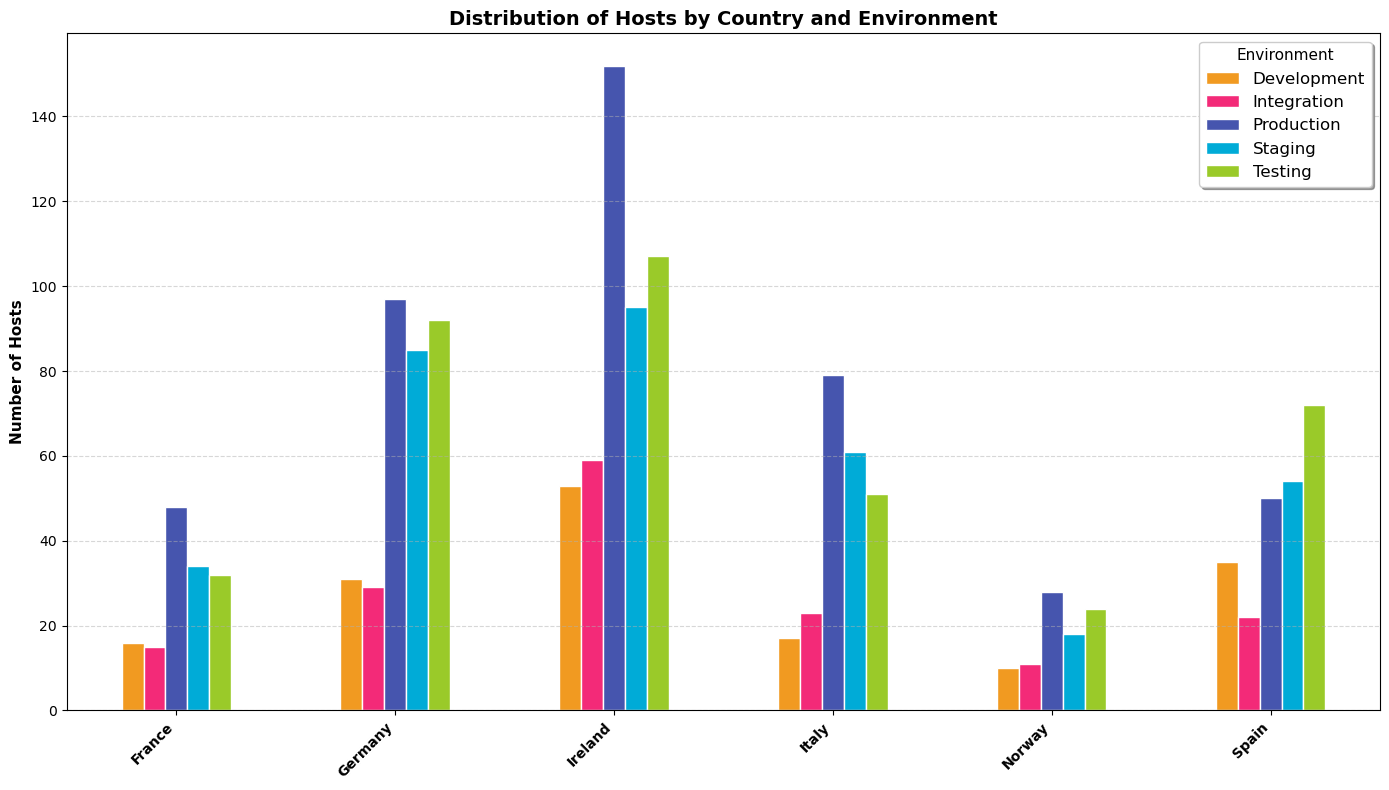

In [77]:
# Group by Country and Environment
environment_by_country = df_hosts.groupby(['country', 'environment']).size().unstack()

# Chart creation and customization
fig, ax = plt.subplots(figsize=(14, 8))
environment_by_country.plot(kind='bar', color=environment_colors, edgecolor='white', ax=ax)

plt.xlabel('')
plt.ylabel('Number of Hosts', fontsize=11, fontweight='bold')
plt.title('Distribution of Hosts by Country and Environment', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.legend(title='Environment', fontsize=12, 
           shadow=True, title_fontsize=11)
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()

**The graph confirms what was expected in the distribution of established hosts when they were created. Ireland and Germany are the ones with the most hosts, with Norway being the country with the fewest hosts. We can see from the composition of the bars that they have a roughly similar percentage. Testing (25%), Staging (25%), and Production (30%) are the values that are most represented in the graph.**

# 11.Hosts by country and environment.

1. `Type of OS grouped by country.`   
2. `Total Operating Systems.`  
3. `Total hosts by country.`   
4. `Hosts by country grouped by environment.`

In [78]:
# Color dictionary for 'Country'
country_colors = {
    'Norway': '#9ACA29',
    'Germany': '#F32A78',
    'Italy':  '#813696',
    'Spain': '#00ABD7',
    'Ireland': '#F9734F',
    'France': '#012290'
}

# Color dictionary for 'Operating System'
os_colors = {
    'Linux': '#4655AE',
    'Solaris': '#F9734F',
    'AIX': '#6E56A0',
    'HP-UX': '#F25D71'
}

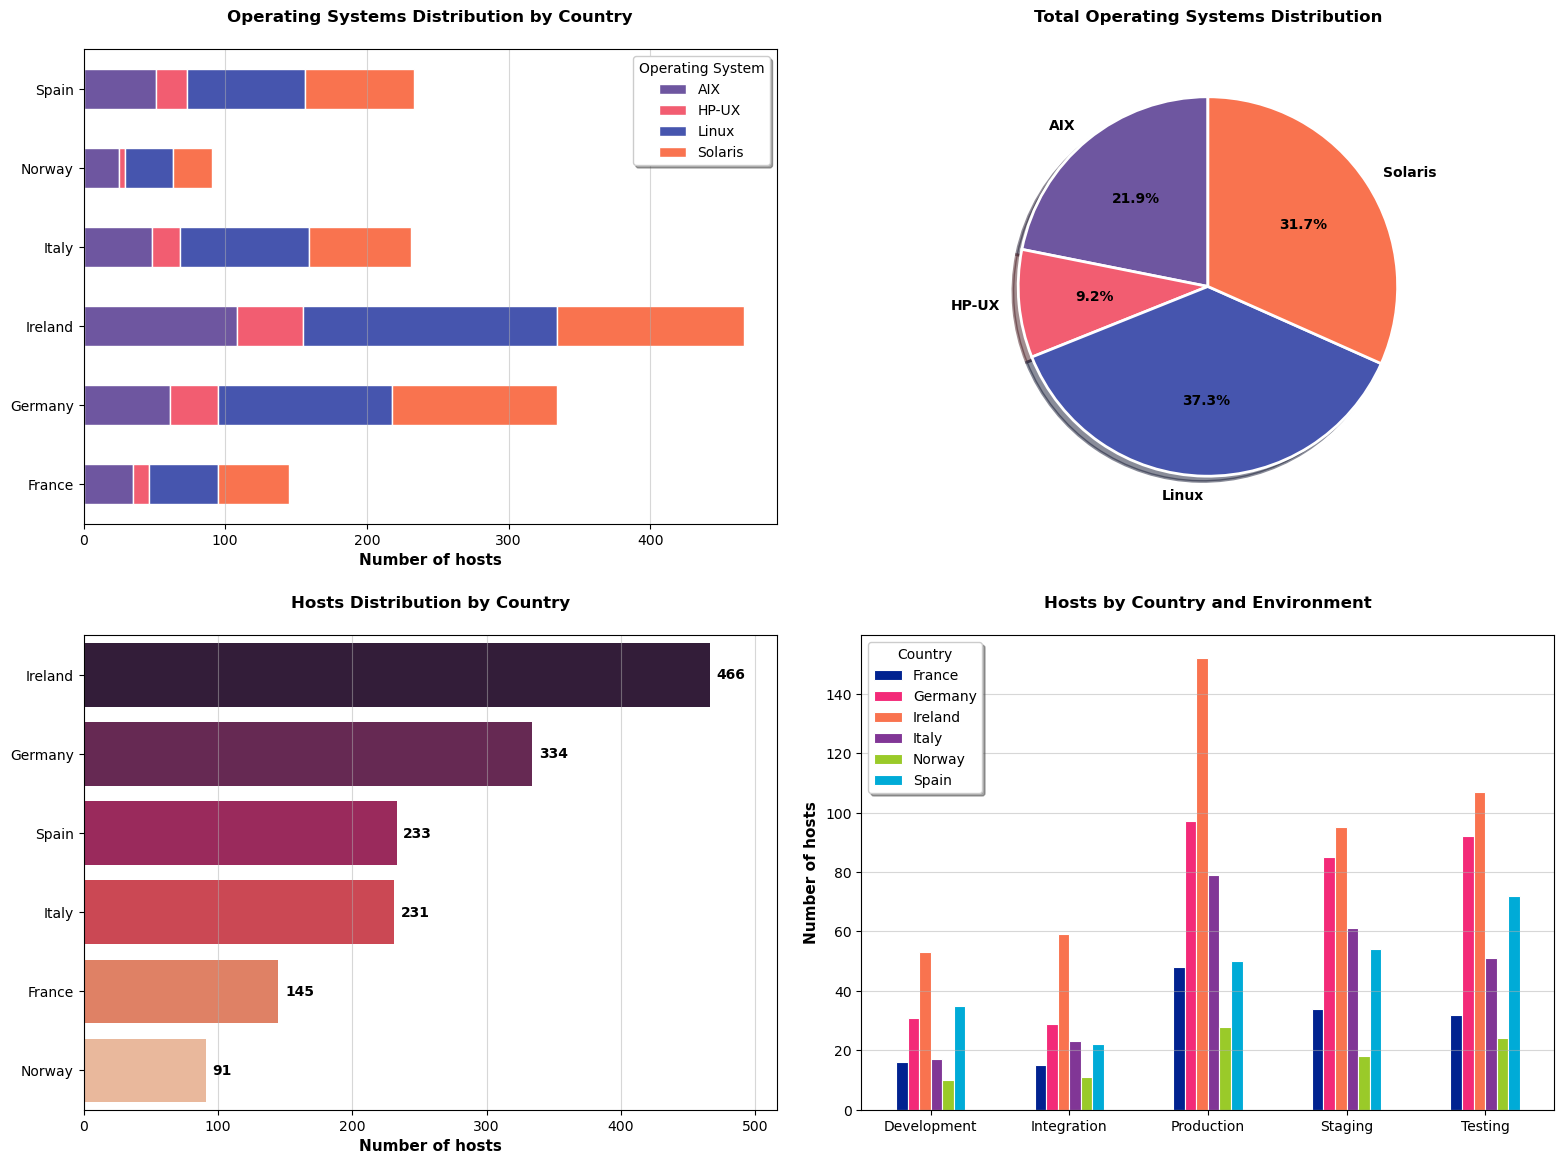

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Type of OS grouped by country
os_by_country = df.groupby(['country', 'os']).size().unstack()

os_country_plot = os_by_country.plot(kind='barh', ax=axes[0, 0], color=os_colors, edgecolor='white', stacked=True)
os_country_plot.set_xlabel('Number of hosts', fontsize=11, fontweight='bold')
os_country_plot.set_ylabel('')
os_country_plot.set_title('Operating Systems Distribution by Country', fontsize=12, fontweight='bold', pad=20)
os_country_plot.legend(title='Operating System', shadow=True)
os_country_plot.grid(axis='x', alpha=0.5)


# 2. Total Operating Systems
os_counts = df.groupby('os').size()
total_os_plot = os_counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 1],
                               colors=[os_colors[os_name] for os_name in os_counts.index],
                               wedgeprops={'edgecolor': 'white', 'linewidth': 2}, shadow=True,
                               startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
total_os_plot.set_ylabel('')
total_os_plot.set_title('Total Operating Systems Distribution', fontsize=12, fontweight='bold', pad=20)


# 3. Total hosts by country
country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['country', 'count']

total_hosts_plot = sns.barplot(
    data=country_counts,
    y='country',
    x='count',
    hue='country',
    legend=False,
    ax=axes[1, 0],
    palette='rocket'
)

total_hosts_plot.set_xlabel('Number of hosts', fontsize=11, fontweight='bold')
total_hosts_plot.set_ylabel('')

for i, v in enumerate(country_counts['count']):
    total_hosts_plot.text(v + 5, i, str(v), ha='left', va='center', fontweight='bold', fontsize=10)

total_hosts_plot.set_xlim(0, country_counts['count'].max() + 50)
total_hosts_plot.set_title('Hosts Distribution by Country', fontsize=12, fontweight='bold', pad=20)
total_hosts_plot.grid(axis='x', alpha=0.5)


# 4. Hosts by country grouped by environment
env_by_country = df.groupby(['country', 'environment']).size().unstack(0)

hosts_by_env = env_by_country.plot(kind='bar', ax=axes[1, 1], color=country_colors, edgecolor='white', linewidth=0.8)
hosts_by_env.set_xlabel('')
hosts_by_env.set_ylabel('Number of hosts', fontsize=11, fontweight='bold')
hosts_by_env.set_title('Hosts by Country and Environment', fontsize=12, fontweight='bold', pad=20)
hosts_by_env.legend(title='Country', shadow=True)
plt.setp(hosts_by_env.xaxis.get_majorticklabels(), rotation=0)
hosts_by_env.grid(axis='y', alpha=0.5)


fig.tight_layout(pad=2.0)
plt.show()

**The distribution of operating system type by country shows that once again Ireland and Germany have the most hosts, with Norway being the country with the fewest. The pie chart shows the percentages of Linux (≈40%), Solaris (≈30%), AIX (≈20%) and HP-UX (≈10%), which continues to confirm the correct creation of hostnames.**

**Ireland with 466(≈30%), Germany with 334 (≈23%), Italy with 231 (≈16%), Spain 233 (≈16%), France 145 (≈9%), and Norway with 91 (≈6%) meet the approximate distributions of the 1500 generated hostnames. Finally, in the environment distribution we see that Production (≈30%) is the highest percentage, followed by Testing and Staging, with Integration and Development being the lowest. This confirms that the hostname proportions are correct.**